In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam

In [ ]:
base_dir = '/content/drive/MyDrive/DATASET'
train_dir = '/content/drive/MyDrive/DATASET/classification/Training'
test_dir = '/content/drive/MyDrive/DATASET/classification/Testing'
seg_dir = '/content/drive/MyDrive/DATASET/Segmentation'

In [ ]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [ ]:
steps_per_epoch = train_gen.samples // BATCH_SIZE
print("Steps per epoch:", steps_per_epoch)

Steps per epoch: 178


In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))

# Freeze base layers (optional, can fine-tune later)
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)  # helps prevent overfitting
x = Dense(128, activation='relu')(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# Define the model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
    return x

def unet_model(input_shape=(128,128,3)):
    inputs = layers.Input(shape=input_shape)
    c1 = conv_block(inputs, 32); p1 = layers.MaxPooling2D((2,2))(c1)
    c2 = conv_block(p1, 64); p2 = layers.MaxPooling2D((2,2))(c2)
    c3 = conv_block(p2, 128); p3 = layers.MaxPooling2D((2,2))(c3)
    c4 = conv_block(p3, 256); p4 = layers.MaxPooling2D((2,2))(c4)
    c5 = conv_block(p4, 512)

    u6 = layers.Conv2DTranspose(256, (2,2), strides=(2,2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4]); c6 = conv_block(u6, 256)
    u7 = layers.Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3]); c7 = conv_block(u7, 128)
    u8 = layers.Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2]); c8 = conv_block(u8, 64)
    u9 = layers.Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1]); c9 = conv_block(u9, 32)

    outputs = layers.Conv2D(1, (1,1), activation='sigmoid')(c9)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

unet = unet_model()
unet.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 256) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 512) │  1,180,160 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 512) │  2,359,808 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    524,544 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 7,760,097 (29.60 MB)

 Trainable params: 7,760,097 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(train_gen,validation_data=test_gen, epochs=2)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
179/179 ━━━━━━━━━━━━━━━━━━━━ 1563s 9s/step - accuracy: 0.5459 - loss: 1.0768 - val_accuracy: 0.7994 - val_loss: 0.4919
Epoch 2/2
179/179 ━━━━━━━━━━━━━━━━━━━━ 1559s 9s/step - accuracy: 0.8499 - loss: 0.4236 - val_accuracy: 0.8505 - val_loss: 0.3791


In [ ]:
history = model.fit(train_gen,validation_data=test_gen, epochs=2)

Epoch 1/2
179/179 ━━━━━━━━━━━━━━━━━━━━ 1581s 9s/step - accuracy: 0.9078 - loss: 0.2569 - val_accuracy: 0.8909 - val_loss: 0.2845
Epoch 2/2
179/179 ━━━━━━━━━━━━━━━━━━━━ 1546s 9s/step - accuracy: 0.9103 - loss: 0.2358 - val_accuracy: 0.8986 - val_loss: 0.2746


In [ ]:
history = model.fit(train_gen,validation_data=test_gen, epochs=1)

179/179 ━━━━━━━━━━━━━━━━━━━━ 1544s 9s/step - accuracy: 0.9168 - loss: 0.2251 - val_accuracy: 0.9054 - val_loss: 0.2593


In [ ]:
def compute_brain_tumor_ratio(img, mask):
    # Ensure grayscale
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if len(mask.shape) == 3:
        mask = mask[:, :, 0]

    # Normalize image to [0, 255]
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

    # Create binary masks
    _, mask_bin = cv2.threshold(mask, 0.5, 1, cv2.THRESH_BINARY)

    # Adaptive brain mask: focus on non-zero regions inside brain area
    _, brain_bin = cv2.threshold(img, 30, 1, cv2.THRESH_BINARY)  # Use higher threshold
    brain_bin = cv2.morphologyEx(brain_bin.astype(np.uint8), cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))

    tumor_pixels = np.sum(mask_bin)
    brain_pixels = np.sum(brain_bin)

    if brain_pixels == 0:
        return 0.0

    ratio = (tumor_pixels / brain_pixels) * 100
    return min(ratio, 100.0)  # Avoid >100% errors


In [ ]:
from tensorflow.image import resize


test_imgs, test_labels = next(test_gen)

# Get predictions from the ResNet50 classifier
pred_classes = model.predict(test_imgs)
pred_class_names = np.array(list(test_gen.class_indices.keys()))[np.argmax(pred_classes, axis=1)]

# Segment only tumor classes (skip "notumour")
seg_pred_ratios = []
seg_pred_masks = []
seg_pred_images = []

for i, cls in enumerate(pred_class_names):
    img = test_imgs[i].copy()
    img = img[..., ::-1]  # Convert BGR -> RGB
    img = np.clip(((img - img.min()) / (img.max() - img.min())) * 255, 0, 255).astype(np.uint8)

    if cls != "notumour":
        # Resize for U-Net
        resized_img = resize(test_imgs[i], (128, 128))
        resized_img = np.expand_dims(resized_img, axis=0)

        # Predict segmentation mask
        seg_mask = unet.predict(resized_img)[0]

        seg_pred_masks.append(seg_mask)
        ratio = compute_brain_tumor_ratio(img, seg_mask)
        seg_pred_ratios.append(ratio)
        seg_pred_images.append(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


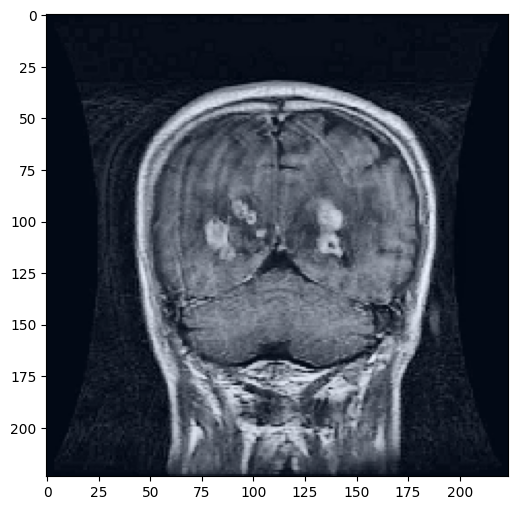

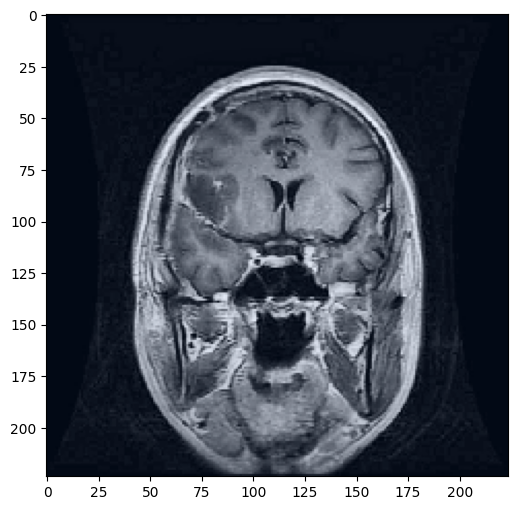

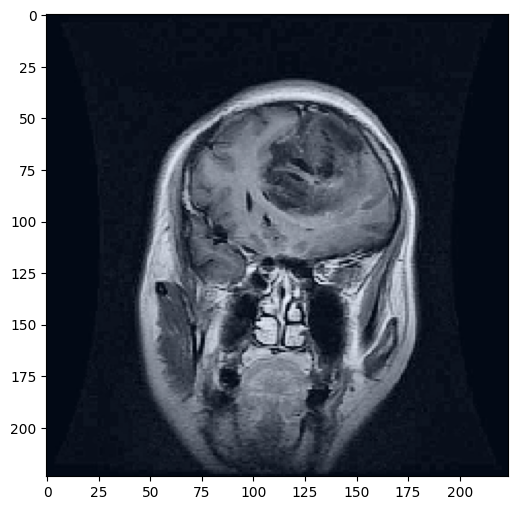

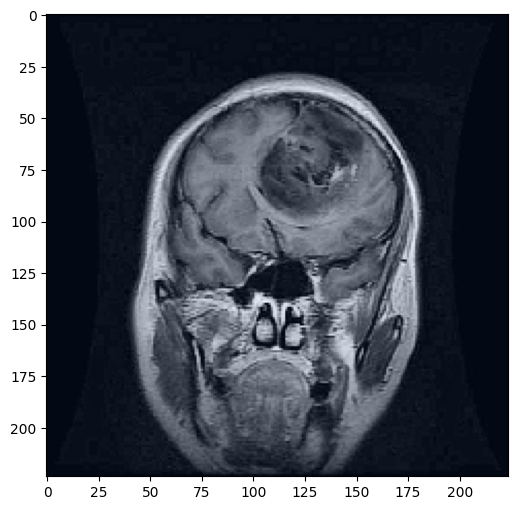

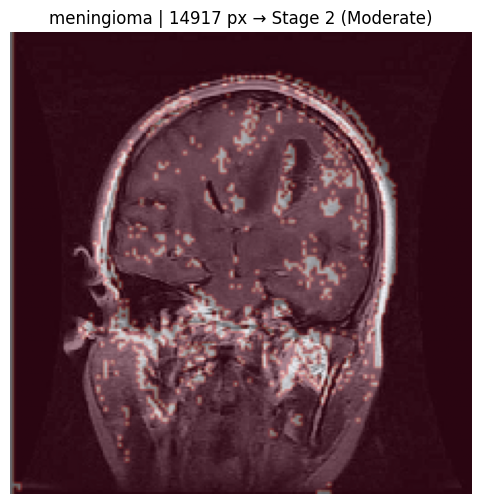

In [ ]:
#STAGE_1_MAX = 5000      Stage 1 (Early)
#STAGE_2_MAX = 15000      Stage 2 (Moderate)
# >15000 → Stage 3 (Advanced)

# Get last batch from test generator
test_imgs, test_labels = next(test_gen)
pred_classes = model.predict(test_imgs)
pred_class_indices = np.argmax(pred_classes, axis=1)
class_names = np.array(list(test_gen.class_indices.keys()))
pred_class_names = class_names[pred_class_indices]

# Use last 5 images
num_to_show = min(5, len(test_imgs))
for i in range(-num_to_show, 0):
    img = test_imgs[i]

    # Undo ResNet50 preprocessing for display
    img_disp = img.copy()
    img_disp = img_disp[..., ::-1]  # BGR -> RGB
    img_disp = np.clip(((img_disp - img_disp.min()) / (img_disp.max() - img_disp.min())) * 255, 0, 255).astype(np.uint8)

    pred_class = pred_class_names[i]

    plt.figure(figsize=(6,6))
    plt.imshow(img_disp)

if pred_class != "notumour":
    from tensorflow.image import resize

    # Prepare input for U-Net
    seg_input = resize(img, (128,128))
    seg_input = np.expand_dims(seg_input, axis=0)

    # Predict mask
    seg_mask = unet.predict(seg_input)[0]      # already a NumPy array
    seg_mask_bin = (seg_mask.squeeze() > 0.5).astype(np.uint8)

    # Resize mask back to original image size
    seg_mask_resized = resize(seg_mask_bin[..., np.newaxis], (img_disp.shape[0], img_disp.shape[1]))
    seg_mask_resized = seg_mask_resized.numpy().squeeze()  # resize returns a tensor
    plt.imshow(seg_mask_resized, cmap='Reds', alpha=0.4)

    # Tumor size and stage
    tumor_size = np.sum(seg_mask_bin)
    if tumor_size < STAGE_1_MAX:
        stage = "Stage 1 (Early)"
    elif tumor_size < STAGE_2_MAX:
        stage = "Stage 2 (Moderate)"
    else:
        stage = "Stage 3 (Advanced)"

    plt.title(f"{pred_class} | {tumor_size} px → {stage}")


    plt.axis('off')
    plt.show()

In [ ]:
last_10_masks = seg_pred_masks[-10:]

print("\nTumor Size-Based Staging (Last 10 Samples):")
for i, mask in enumerate(last_10_masks, start=len(seg_pred_masks)-9):
    # Ensure binary mask
    mask_bin = (mask > 0.5).astype(np.uint8)
    tumor_size = np.sum(mask_bin)  # number of pixels

    # Assign stage
    if tumor_size < 5000:
        stage = "Stage 1 (Early)"
    elif tumor_size < 15000:
        stage = "Stage 2 (Moderate)"
    else:
        stage = "Stage 3 (Advanced)"

    print(f"Image {i}: Tumor size = {tumor_size} pixels → {stage}")


Tumor Size-Based Staging (Last 10 Samples):
Image 23: Tumor size = 15384 pixels → Stage 3 (Advanced)
Image 24: Tumor size = 14586 pixels → Stage 2 (Moderate)
Image 25: Tumor size = 15071 pixels → Stage 3 (Advanced)
Image 26: Tumor size = 15871 pixels → Stage 3 (Advanced)
Image 27: Tumor size = 14154 pixels → Stage 2 (Moderate)
Image 28: Tumor size = 14941 pixels → Stage 2 (Moderate)
Image 29: Tumor size = 14479 pixels → Stage 2 (Moderate)
Image 30: Tumor size = 14069 pixels → Stage 2 (Moderate)
Image 31: Tumor size = 14385 pixels → Stage 2 (Moderate)
Image 32: Tumor size = 14505 pixels → Stage 2 (Moderate)


In [ ]:
from sklearn.metrics import classification_report
test_gen.reset()

# Predict on entire test set
pred_probs = model.predict(test_gen, verbose=1)
pred_indices = np.argmax(pred_probs, axis=1)

# True labels from generator
true_indices = test_gen.classes

# Class names in the same order as test_gen
class_names = list(test_gen.class_indices.keys())

print(classification_report(true_indices, pred_indices, target_names=class_names))

41/41 ━━━━━━━━━━━━━━━━━━━━ 293s 7s/step
              precision    recall  f1-score   support

      glioma       0.98      0.79      0.88       300
  meningioma       0.77      0.86      0.81       306
     notumor       0.94      0.99      0.96       405
   pituitary       0.96      0.95      0.95       300

    accuracy                           0.91      1311
   macro avg       0.91      0.90      0.90      1311
weighted avg       0.91      0.91      0.91      1311



In [ ]:
#Dataset Generation for BI Visualization
import pandas as pd
import numpy as np

# Get your class names from the generator
class_names = list(test_gen.class_indices.keys())

# 1️ Model predictions on test data
pred_classes = model.predict(test_gen)
pred_labels = np.argmax(pred_classes, axis=1)
pred_class_names = np.array(class_names)[pred_labels]

# 2️ True labels
true_labels = test_gen.classes
true_class_names = np.array(class_names)[true_labels]

# 3️ Confidence (highest predicted probability)
confidence_scores = np.max(pred_classes, axis=1)

# 4️ Accuracy flag (1 = correct, 0 = wrong)
accuracy_flags = (pred_labels == true_labels).astype(int)

# 5️ Create the dataset
df = pd.DataFrame({
    'image_path': test_gen.filenames,
    'true_label': true_class_names,
    'predicted_label': pred_class_names,
    'confidence_score': confidence_scores,
    'accuracy': accuracy_flags
})

# 6️ Add class probabilities
for i, name in enumerate(class_names):
    df[name + '_prob'] = pred_classes[:, i]

# 8️ Save as CSV file
df.to_csv('brain_tumor.csv', index=False)

